<a href="https://colab.research.google.com/github/sshafaa/Proyek-Data-Mining-R1-Kelompok-5/blob/main/PROYEK_DATMIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_excel('data siswa.xlsx')

In [ ]:
df

,No,Nama Siswa,Cognitive Load,Resiliensi
0,1,Andaru Azkha Aranatama,82,45
1,2,Anggita Septi Tree Rahayu,76,50
2,3,Aria Huda Galuh,35,88
3,4,Arieffatul Umami,40,85
4,5,Arkana Ezar Altaffiras Isnanto,60,65
5,6,Askana Adzra Farrastra,58,70
6,7,Calista Puteri Sabina,90,35
7,8,Chesa Kenzie Yusuf Asadel,88,38
8,9,Cindy Aulia,45,82
9,10,Icha Aulia Rahma,55,68


Pre-Processing

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   No              34 non-null     int64 
 1   Nama Siswa      34 non-null     object
 2   Cognitive Load  34 non-null     int64 
 3   Resiliensi      34 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 1.2+ KB
None


In [ ]:
print(df.isnull().sum())

No                0
Nama Siswa        0
Cognitive Load    0
Resiliensi        0
dtype: int64


In [ ]:
x = df[['Cognitive Load','Resiliensi']]

In [ ]:
x

,Cognitive Load,Resiliensi
0,82,45
1,76,50
2,35,88
3,40,85
4,60,65
5,58,70
6,90,35
7,88,38
8,45,82
9,55,68


In [ ]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [ ]:
x_scaled

array([[ 1.25829892, -1.19155923],
       [ 0.9308844 , -0.92290529],
       [-1.30644811,  1.11886463],
       [-1.03360268,  0.95767227],
       [ 0.05777903, -0.11694348],
       [-0.05135914,  0.15171046],
       [ 1.6948516 , -1.7288671 ],
       [ 1.58571343, -1.56767474],
       [-0.76075725,  0.79647991],
       [-0.2150664 ,  0.04424888],
       [-1.57929354,  1.33378778],
       [ 0.71260806, -0.65425135],
       [-0.59705   ,  0.68901833],
       [ 0.1669172 , -0.22440505],
       [ 1.42200617, -1.35275159],
       [-1.14274085,  1.17259542],
       [-0.37877365,  0.25917203],
       [ 1.04002257, -1.03036687],
       [-0.92446451,  0.90394148],
       [ 0.33062446, -0.38559742],
       [-1.41558628,  1.22632621],
       [ 1.14916074, -1.13782844],
       [-0.48791182,  0.4203644 ],
       [-0.65161908,  0.58155676],
       [ 0.82174623, -0.76171293],
       [-1.25187902,  1.22632621],
       [ 0.49433172, -0.49305899],
       [ 1.80398977, -1.99752104],
       [-0.97903359,

Elbow Method

In [ ]:
wcs = []

for i in range(1,11):
  kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
  kmeans.fit(x_scaled)
  wcs.append(kmeans.inertia_)

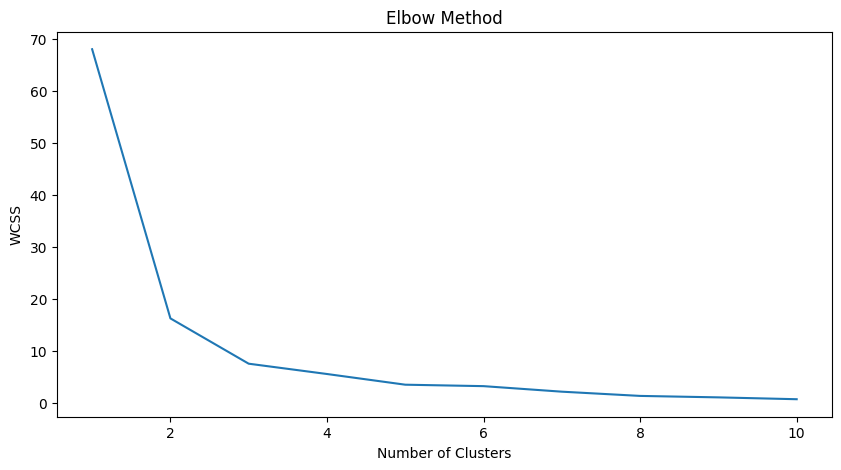

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(range(1,11), wcs)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

Pemodelan K-Means

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42
)

In [ ]:
cluster = kmeans.fit_predict(x_scaled)

In [ ]:
df['Cluster'] = cluster

Evaluasi

In [ ]:
silhouette = silhouette_score(x_scaled, cluster)

In [ ]:
silhouette

np.float64(0.5586620334824896)

In [ ]:
print("Hasil Clustering")
print(df)

Hasil Clustering
    No                        Nama Siswa  Cognitive Load  Resiliensi  Cluster
0    1            Andaru Azkha Aranatama              82          45        1
1    2         Anggita Septi Tree Rahayu              76          50        1
2    3                   Aria Huda Galuh              35          88        0
3    4                  Arieffatul Umami              40          85        0
4    5    Arkana Ezar Altaffiras Isnanto              60          65        2
5    6            Askana Adzra Farrastra              58          70        2
6    7             Calista Puteri Sabina              90          35        1
7    8         Chesa Kenzie Yusuf Asadel              88          38        1
8    9                       Cindy Aulia              45          82        0
9   10                  Icha Aulia Rahma              55          68        2
10  11                     Ika Fatmawati              30          92        0
11  12               Isna Afa Nada Delia       

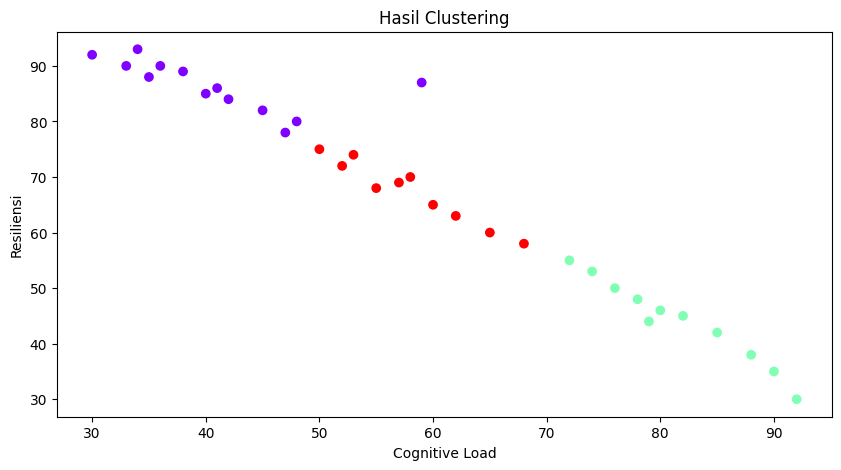

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(
    df['Cognitive Load'],
    df['Resiliensi'],
    c=df['Cluster'],
    cmap='rainbow'
)
plt.xlabel('Cognitive Load')
plt.ylabel('Resiliensi')
plt.title('Hasil Clustering')
plt.show()

In [ ]:
print("Anggota Setiap Cluster")

for i in sorted(df['Cluster'].unique()):
  print(f"Cluster {i}")
  anggota = df[df['Cluster'] == i]['Nama Siswa']
  for nama in anggota:
    print("-",nama)

Anggota Setiap Cluster
Cluster 0
- Aria Huda Galuh
- Arieffatul Umami
- Cindy Aulia
- Ika Fatmawati
- Jagat Pramudhita M
- Muhammad Azwangga Reyhan Fahreza
- Muhammad Rafka Alfarezi
- Naufal Alif Wijaya
- Nayla Fauzia Azzahra Nugraha
- Raditiya Praba Perwira
- Salim Khoirul Lisan
- Sayyid Hasan Al Anshory
- Tania Uzlah Wahyu Bachtiar
Cluster 1
- Andaru Azkha Aranatama
- Anggita Septi Tree Rahayu
- Calista Puteri Sabina
- Chesa Kenzie Yusuf Asadel
- Isna Afa Nada Delia
- Miftahul Jannah
- Muhammad Rafi Maulana
- Naufal Haidar Ahmad
- Prince Gabriel Leonard Al Jabbar
- Sakhi Almer Faidh
- Sayyidina Zafar Alhamzah
Cluster 2
- Arkana Ezar Altaffiras Isnanto
- Askana Adzra Farrastra
- Icha Aulia Rahma
- Kania Amelia Artanti
- Muhammad Prabu Penggalih
- Naufal Adil Fadhila
- Naufal Satria Nur Rasyid
- Radittya Putra Rifa'i
- Salsabila Syfa Ramadhani
- Shofiya Nadaa Khoirunnisa
